In [3]:
from src.data.loading_data import load_dataset, load_fraud_dataset, load_non_fraud_dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'src'

In [1]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
dataset = load_dataset()
dataset_fraud = load_fraud_dataset()
dataset.head()

NameError: name 'load_dataset' is not defined

In [ ]:
x_data = dataset.drop("Class", axis=1)
y_data = dataset["Class"]
x_data_fraud = dataset_fraud.drop("Class", axis=1)
y_data_fraud = dataset_fraud["Class"]

In [ ]:
vx = 'V11'

/var/folders/fp/dpzvj70s7vs2xby2sw6lv2j40000gn/T/ipykernel_65663/3407279672.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


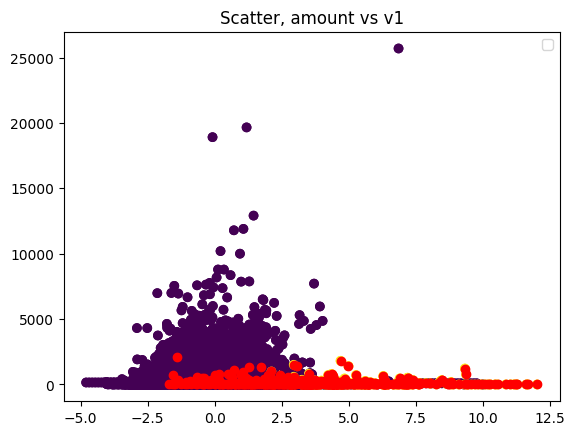

In [ ]:
plt.scatter(x_data[vx],x_data['Amount'],  c=y_data)
plt.scatter(x_data[vx],x_data['Amount'],  c=y_data)
plt.scatter(x_data_fraud[vx],x_data_fraud['Amount'],  c='red')
plt.legend()
plt.title("Scatter, amount vs v1")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

In [ ]:
pipeline_base = make_pipeline(RobustScaler())
preprocessor = make_column_transformer((pipeline_base, ['Amount', 'Time']), remainder='passthrough')
model = make_pipeline(preprocessor, LogisticRegression(class_weight="balanced", max_iter=2900))
model.named_steps
model.fit(x_train, y_train)


/Users/fabiochaput/Documents/VS/portfolio/.venv/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Amount', 'Time'])])),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=2900))])

In [ ]:

model.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('pipeline',
                                    Pipeline(steps=[('robustscaler',
                                                     RobustScaler())]),
                                    ['Amount', 'Time'])])),
  ('logisticregression',
   LogisticRegression(class_weight='balanced', max_iter=2900))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('pipeline',
                                  Pipeline(steps=[('robustscaler',
                                                   RobustScaler())]),
                                  ['Amount', 'Time'])]),
 'logisticregression': LogisticRegression(class_weight='balanced', max_iter=2900),
 'columntransformer__force_int_remainder_cols': True,
 'columntransformer__n_jobs': None,
 'columntransformer__remainder': 'passthro

In [ ]:
# param_grid ={
#         'logisticregression__penalty': ['l2'],
#         'logisticregression__solver': ['lbfgs', 'sag'],
#         'logisticregression__C': [0.01, 0.1, 1, 10]
#     }
# grid = GridSearchCV(model, param_grid, cv=3, scoring='recall', n_jobs=-1)
# grid.fit(x_train, y_train)
# grid.best_params_



In [ ]:
model = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs', class_weight='balanced')

In [ ]:
model.fit(x_train, y_train)
model.score(x_test, y_test)


/Users/fabiochaput/Documents/VS/portfolio/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9605526491345108

In [ ]:
y_pred = model.predict(x_test)

NameError: name 'model' is not defined

In [ ]:
a = confusion_matrix(y_pred, y_test)

In [ ]:
print(f"{a[1][1] / (a[1][0] + a[1][1])*100:.2f}% des fraudes ont ete detectes")
print(f"Le score du modele est cependant impressionant avec un score de {model.score(x_test, y_test)*100:.2f}%")


3.86% des fraudes ont ete detectes
Le score du modele est cependant impressionant avec un score de 96.06%


<Axes: >

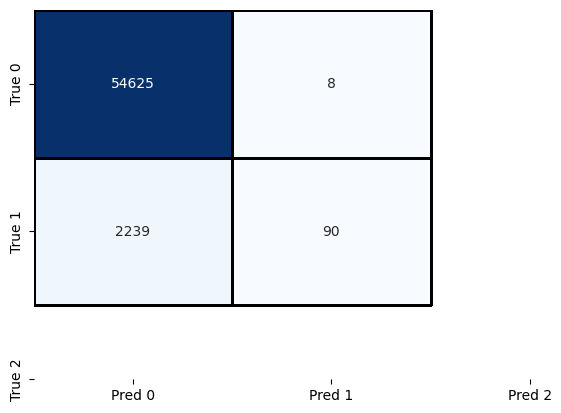

In [ ]:

sns.heatmap(confusion_matrix(y_pred, y_test),
                annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1", "Pred 2"],
    yticklabels=["True 0", "True 1", "True 2"],
    linewidths=1,
    linecolor="black")

On va se faire un autre model qui sera plus adapte, XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
XGBClassifier()

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)


In [ ]:
pipeline = Pipeline([
    ("model", model)
])

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


In [ ]:
y_proba = grid.predict_proba(x_test)[:, 1]
y_proba

array([0.03381851, 0.01715518, 0.4610462 , ..., 0.01502077, 0.00938914,
       0.03997522], dtype=float32)

In [ ]:
best_threshold = 0
best_precision = 0
min_recall = 0.8

for t in np.arange(0.1, 1.0, 0.01):
    y_pred = (y_proba > t).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_fraude = report["1"]["precision"]
    recall_fraude = report["1"]["recall"]
    
    if recall_fraude >= min_recall and precision_fraude > best_precision:
        best_precision = precision_fraude
        best_threshold = t

print(f"\nThreshold conseillé : {best_threshold:.2f}")
print(f"Precision : {best_precision:.2f}")


Threshold conseillé : 0.96
Precision : 0.73


Le cas des Fraudes de cartes de crewdit est relativement simple pour XGBoost, donc il est presque sur de lui a chaque fraude, de ce fait, le point d equilibre entre precision et recall est atteint a 0.96

In [ ]:
y_pred = (y_proba > best_threshold).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[56835    29]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.82      0.77        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.metrics import precision_recall_curve

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# aligner lengths pour plot
thresholds_ext = np.append(thresholds, 1.0)

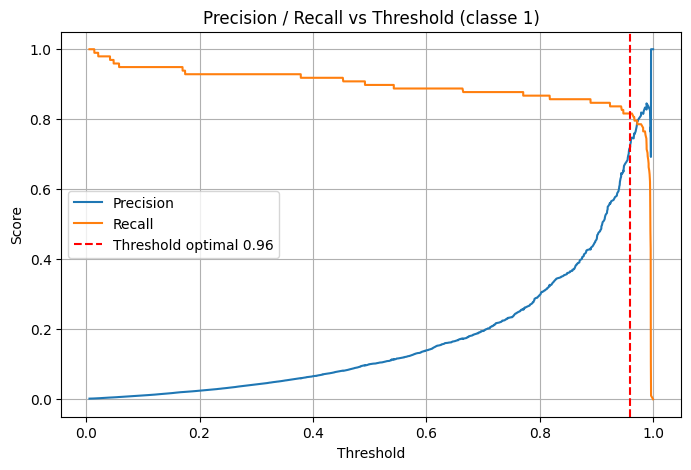

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(thresholds_ext, precision, label="Precision")
plt.plot(thresholds_ext, recall, label="Recall")
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Threshold optimal {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Threshold (classe 1)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
x_topredict = dataset[0:1].drop("Class", axis=1)
y_result = dataset[0:1]["Class"].values[0]

In [ ]:
x_topredict

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62


In [ ]:
model.predict(x_topredict)

NotFittedError: need to call fit or load_model beforehand

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 